# Step 0: Imports and Reading Data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

PATH_CSV = Path("../data/raw/tracks_features.csv")

In [2]:
# load CSV
df = pd.read_csv(PATH_CSV)

# Step 1: Data Understanding
- Dataframe `shape`
- `head` and `tail`
- `dtypes`
- `describe`

In [3]:
# info about our data (Row, Columns)
print("Shape (Row, Columns): ", df.shape)

Shape (Row, Columns):  (1204025, 24)


In [4]:
# view top 5 of the data
df.head(5)
# df.tail(5)

,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,0.978,7,-5.399,1,0.0727,0.02610,0.000011,0.3560,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,0.957,11,-5.764,1,0.1880,0.01290,0.000071,0.1550,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,0.970,7,-5.424,1,0.4830,0.02340,0.000002,0.1220,0.370,149.749,298893,4.0,1999,1999-11-02
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],4,1,True,0.440,0.967,11,-5.830,0,0.2370,0.16300,0.000004,0.1210,0.574,96.752,213640,4.0,1999,1999-11-02
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],5,1,False,0.426,0.929,2,-6.729,1,0.0701,0.00162,0.105000,0.0789,0.539,127.059,205600,4.0,1999,1999-11-02


In [5]:
# get column names
df.columns

Index(['id', 'name', 'album', 'album_id', 'artists', 'artist_ids',
       'track_number', 'disc_number', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'time_signature', 'year', 'release_date'],
      dtype='str')

In [6]:
# get column types
df.dtypes

id                      str
name                    str
album                   str
album_id                str
artists                 str
artist_ids              str
track_number          int64
disc_number           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
duration_ms           int64
time_signature      float64
year                  int64
release_date            str
dtype: object

In [7]:
# detailed info about our data
df.describe()

,track_number,disc_number,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year
count,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06
mean,7.656352e+00,1.055906e+00,4.930565e-01,5.095363e-01,5.194151e+00,-1.180870e+01,6.714595e-01,8.438219e-02,4.467511e-01,2.828605e-01,2.015994e-01,4.279866e-01,1.176344e+02,2.488399e+05,3.832494e+00,2.007328e+03
std,5.994977e+00,2.953752e-01,1.896694e-01,2.946839e-01,3.536731e+00,6.982132e+00,4.696827e-01,1.159914e-01,3.852014e-01,3.762844e-01,1.804591e-01,2.704846e-01,3.093705e+01,1.622104e+05,5.611826e-01,1.210117e+01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00
25%,3.000000e+00,1.000000e+00,3.560000e-01,2.520000e-01,2.000000e+00,-1.525400e+01,0.000000e+00,3.510000e-02,3.760000e-02,7.600000e-06,9.680000e-02,1.910000e-01,9.405400e+01,1.740900e+05,4.000000e+00,2.002000e+03
50%,7.000000e+00,1.000000e+00,5.010000e-01,5.240000e-01,5.000000e+00,-9.791000e+00,1.000000e+00,4.460000e-02,3.890000e-01,8.080000e-03,1.250000e-01,4.030000e-01,1.167260e+02,2.243390e+05,4.000000e+00,2.009000e+03
75%,1.000000e+01,1.000000e+00,6.330000e-01,7.660000e-01,8.000000e+00,-6.717000e+00,1.000000e+00,7.230000e-02,8.610000e-01,7.190000e-01,2.450000e-01,6.440000e-01,1.370460e+02,2.858400e+05,4.000000e+00,2.015000e+03
max,5.000000e+01,1.300000e+01,1.000000e+00,1.000000e+00,1.100000e+01,7.234000e+00,1.000000e+00,9.690000e-01,9.960000e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.489340e+02,6.061090e+06,5.000000e+00,2.020000e+03


# Step 2: Data Preperations
- Dropping irrelevant columns and rows
- Identifying duplicated columns
- Renaming Columns
- Feature Creation

## Metadata Cols
- id
- name
- artists

## Feature Cols
- danceability
- energy
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo

In [8]:
METADATA_COLS = ["id", "name", "artists"]
FEATURE_COLS = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

# make a copy with only the needed features
df = df[METADATA_COLS + FEATURE_COLS].copy()

In [9]:
# checking if the copy worked
print("Shape (Row, Columns): ", df.shape)

Shape (Row, Columns):  (1204025, 12)


In [10]:
# checking if any wrong type
df.dtypes

id                      str
name                    str
artists                 str
danceability        float64
energy              float64
loudness            float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
dtype: object

In [11]:
# checking if there are any missing values aka. N/A
df.isna().sum()

id                  0
name                3
artists             0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64

In [12]:
# checking if there are any duplicated values in our dataset
df.loc[df.duplicated()]

,id,name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo


In [13]:
# checking for any duplicated id
df.loc[df.duplicated(subset=['id'])]

,id,name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo


In [14]:
# there is a chance of a song has a duplicated from the same artist (e.g. 2 diff album that contains the same song)
# so we are only taking the ones that are not duplicated
df = df.loc[~df.duplicated(subset=['name', 'artists'])] \
       .reset_index(drop=True).copy()

df.head()

,id,name,artists,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,['Rage Against The Machine'],0.470,0.978,-5.399,0.0727,0.02610,0.000011,0.3560,0.503,117.906
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,['Rage Against The Machine'],0.599,0.957,-5.764,0.1880,0.01290,0.000071,0.1550,0.489,103.680
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,['Rage Against The Machine'],0.315,0.970,-5.424,0.4830,0.02340,0.000002,0.1220,0.370,149.749
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,['Rage Against The Machine'],0.440,0.967,-5.830,0.2370,0.16300,0.000004,0.1210,0.574,96.752
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,['Rage Against The Machine'],0.426,0.929,-6.729,0.0701,0.00162,0.105000,0.0789,0.539,127.059


> `\` is used to break up the chaining methods to a new line, reducing clutter

# Step 3: Feature Understanding
(Univariate analysis)
- Plotting feature Distributions
    - Histogram
    - KDE
    - Boxplot

Text(0, 0.5, 'Artists name')

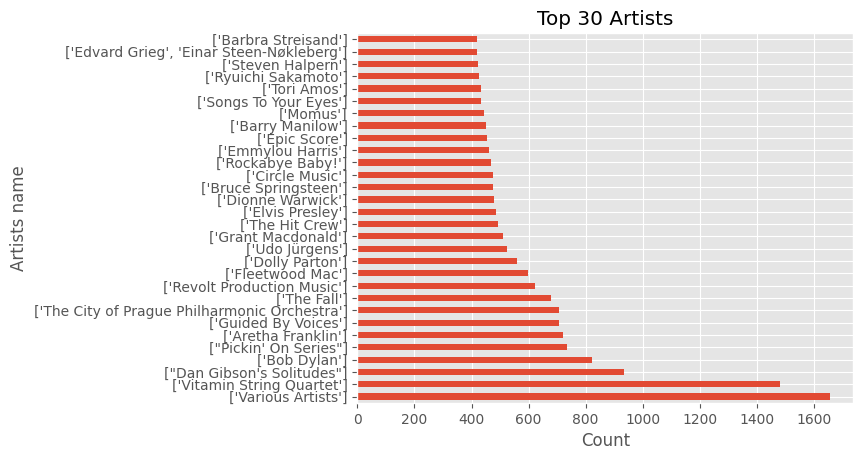

In [15]:
# visualizing the top artists
ax = df['artists'].value_counts() \
    .head(30) \
    .plot(kind='barh', title='Top 30 Artists')
ax.set_xlabel('Count')
ax.set_ylabel('Artists name')

Text(0.5, 0, 'Danceability Score')

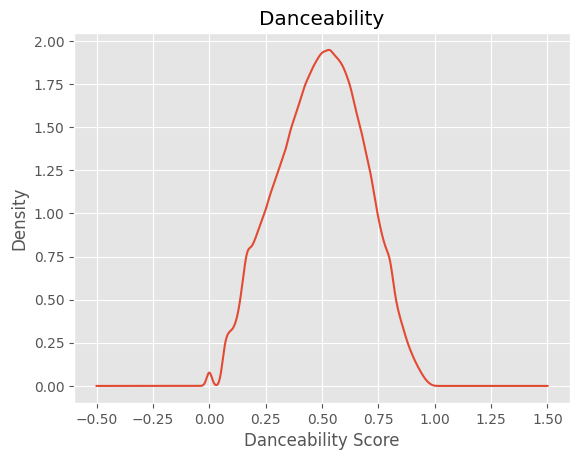

In [16]:
ax = df['danceability'].plot(kind='kde', title='Danceability')
ax.set_xlabel('Danceability Score')

Text(0.5, 0, 'Energy Score')

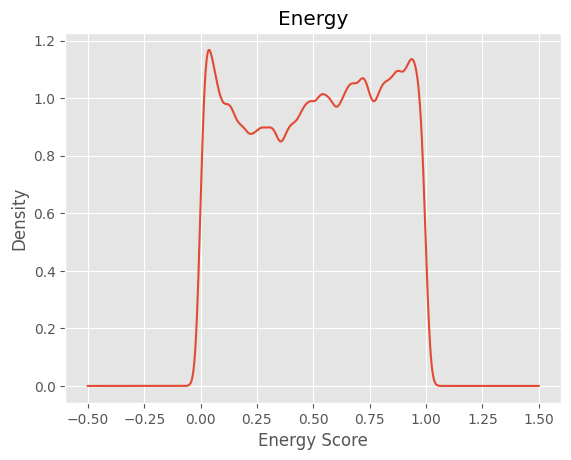

In [17]:
ax = df['energy'].plot(kind='kde', title='Energy')
ax.set_xlabel('Energy Score')

Text(0.5, 0, 'Loudness Score')

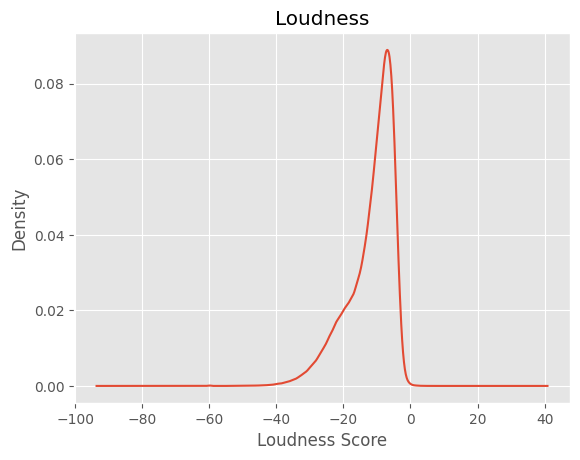

In [18]:
ax = df['loudness'].plot(kind='kde', title='Loudness')
ax.set_xlabel('Loudness Score')

Text(0.5, 0, 'Speechiness Score')

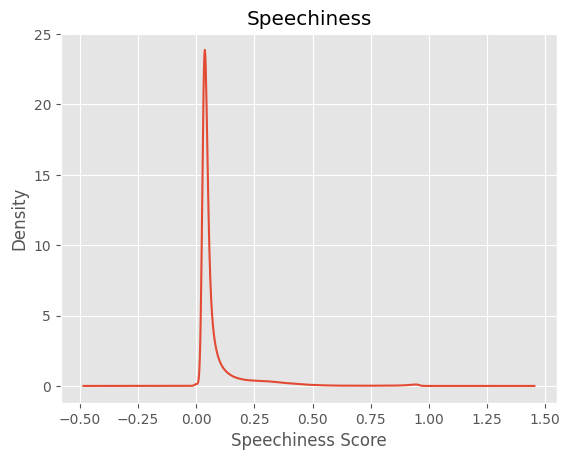

In [19]:
ax = df['speechiness'].plot(kind='kde', title='Speechiness')
ax.set_xlabel('Speechiness Score')

Text(0.5, 0, 'Acousticness Score')

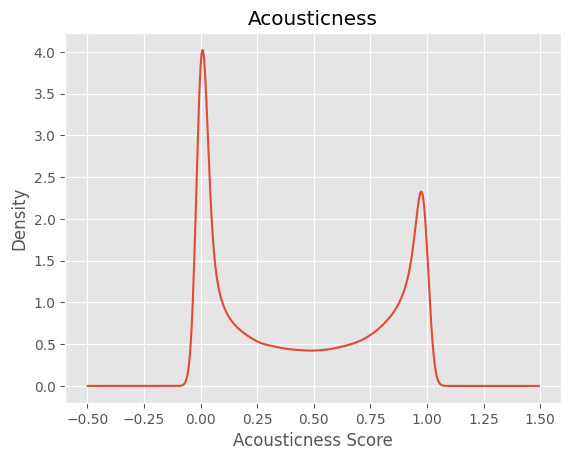

In [20]:
ax = df['acousticness'].plot(kind='kde', title='Acousticness')
ax.set_xlabel('Acousticness Score')

Text(0.5, 0, 'Instrumentalness Score')

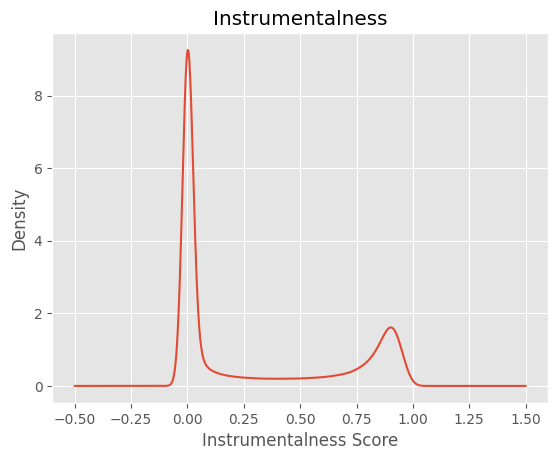

In [21]:
ax = df['instrumentalness'].plot(kind='kde', title='Instrumentalness')
ax.set_xlabel('Instrumentalness Score')

Text(0.5, 0, 'Liveness Score')

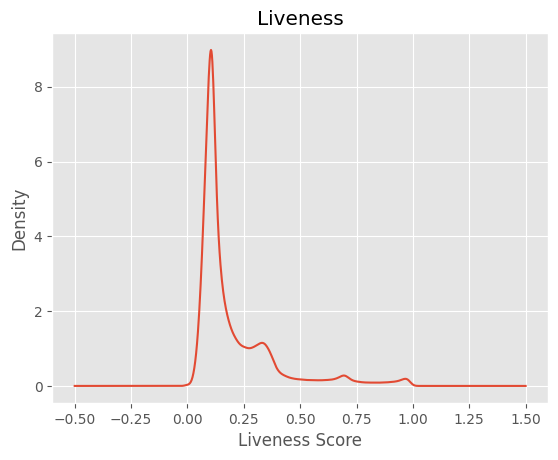

In [22]:
ax = df['liveness'].plot(kind='kde', title='Liveness')
ax.set_xlabel('Liveness Score')

Text(0.5, 0, 'Valence Score')

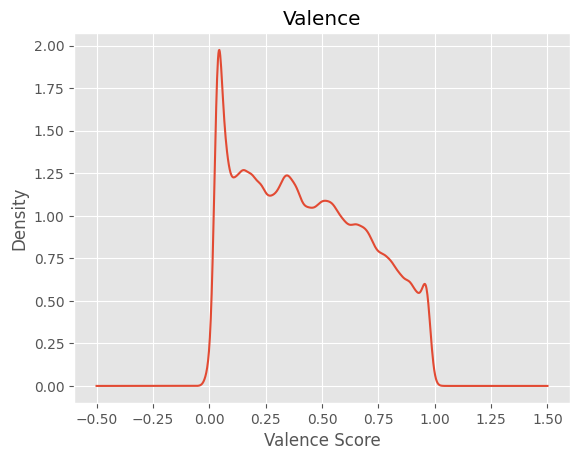

In [23]:
ax = df['valence'].plot(kind='kde', title='Valence')
ax.set_xlabel('Valence Score')

Text(0.5, 0, 'Tempo')

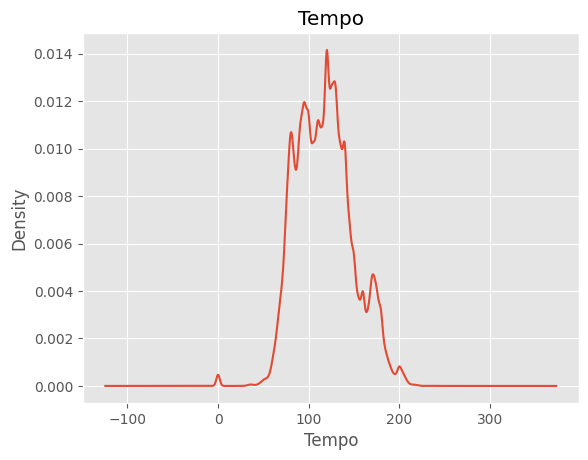

In [24]:
ax = df['tempo'].plot(kind='kde', title='Tempo')
ax.set_xlabel('Tempo')

# Step 4: Feature Relationships
- Scatterplot
- Heatmap Correlation
- Pairplot
- Groupy comparisons

In [25]:
df_corr = df[FEATURE_COLS].dropna().corr()

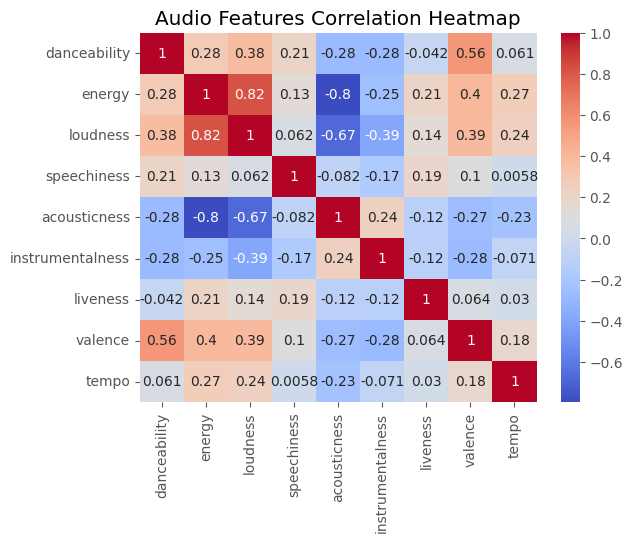

In [26]:
# correlation heatmap of each features
# plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.title("Audio Features Correlation Heatmap")
plt.show()

in our heatmap right now, we have encountered a problem named `Double-Counting`

`Double-Counting` means that there are 2 features that measures the same thing, just with different numbers
if we were to fed it into out ML algorithm right now, the ML algorithm doesn't understand if both are measuring the exact same thing, it would think it's two different requirements
because of that, it would make a bias towards the 2 features. it would accidentally think it's twice as important

we would flag a correlation `Double-Counting` if it's >= 0.75

---

in this case, our the features loudness and energy in our dataset is `Double-Counting`
so we would need to drop either one of the features. i am going to drop the loudness

In [27]:
# removed loudness because it's double-counting
FEATURE_COLS = ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

features = df[FEATURE_COLS]

# Step 5: Ask a Question about the data
- Try to answer a question you have about the data using a plot or statistic

## Questions
1. Does a song need to be fast (high tempo) for it to be highly danceable, or is there a "sweet spot" for dancing?
2. Are happy songs (valence) always energetic (energy)?
3. Are acoustic songs more likely to be recorded live

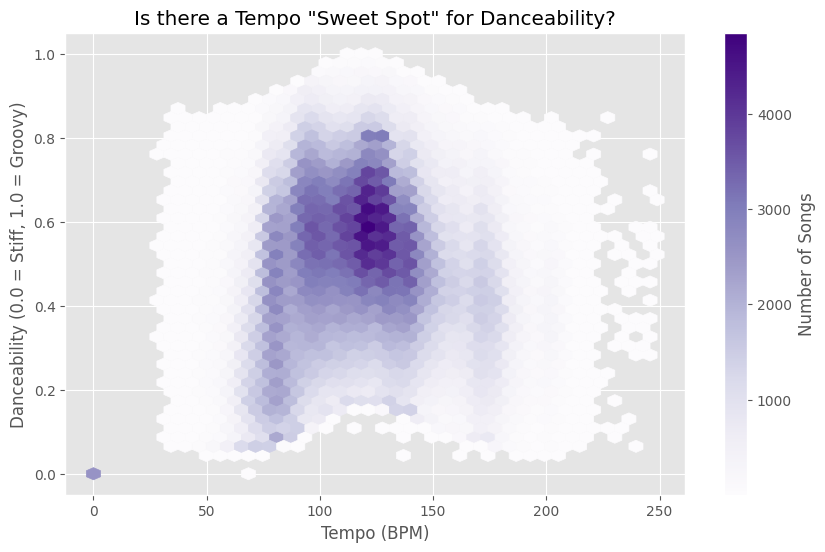

In [29]:
# Question 1
plt.figure(figsize=(10, 6))
# A hexbin plot calculates density. 'gridsize' controls the size of the hexagons.
plt.hexbin(x=df['tempo'], y=df['danceability'], gridsize=40, cmap='Purples', mincnt=1)
plt.colorbar(label='Number of Songs')

plt.title('Is there a Tempo "Sweet Spot" for Danceability?')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Danceability (0.0 = Stiff, 1.0 = Groovy)')
plt.show()

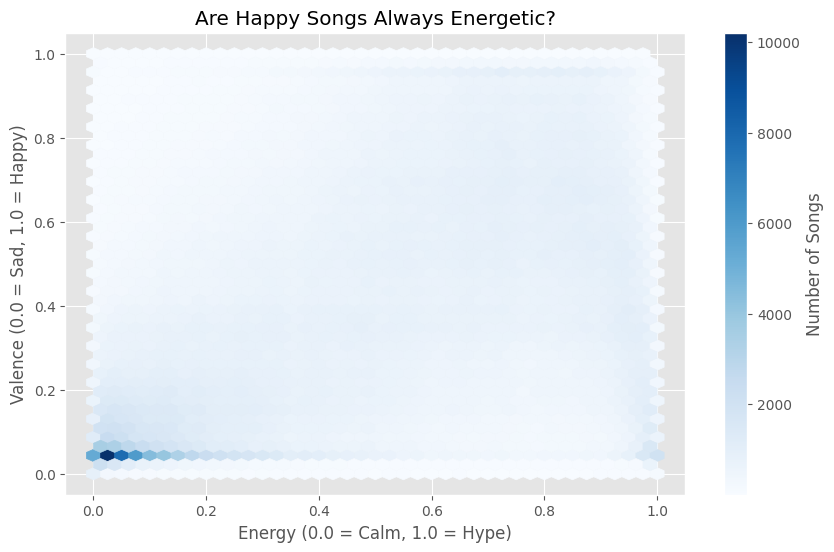

In [30]:
# Question 2
plt.figure(figsize=(10, 6))
plt.hexbin(x=df['energy'], y=df['valence'], gridsize=40, cmap='Blues', mincnt=1)
plt.colorbar(label='Number of Songs')

plt.title('Are Happy Songs Always Energetic?')
plt.xlabel('Energy (0.0 = Calm, 1.0 = Hype)')
plt.ylabel('Valence (0.0 = Sad, 1.0 = Happy)')
plt.show()

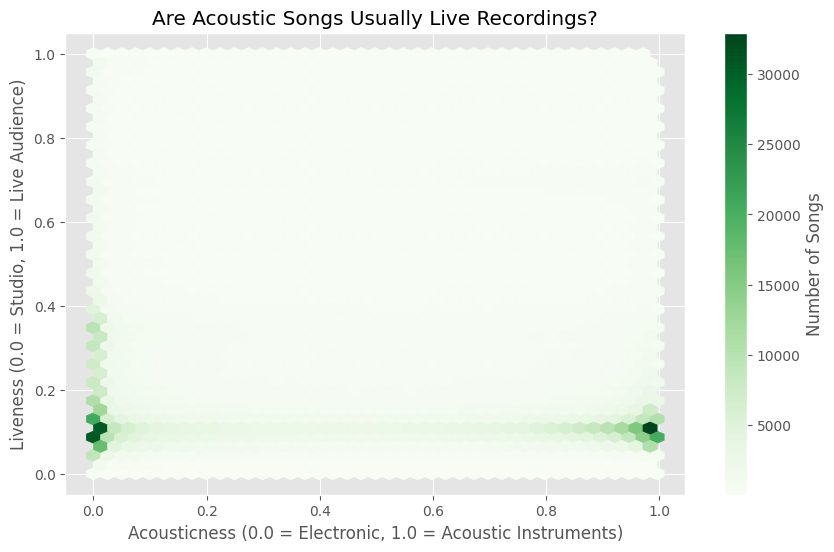

In [31]:
# Question 3
# According to Spotify's API, liveness score >= 0.8 are recorded in front of a live audience
plt.figure(figsize=(10, 6))
plt.hexbin(x=df['acousticness'], y=df['liveness'], gridsize=40, cmap='Greens', mincnt=1)
plt.colorbar(label='Number of Songs')

plt.title('Are Acoustic Songs Usually Live Recordings?')
plt.xlabel('Acousticness (0.0 = Electronic, 1.0 = Acoustic Instruments)')
plt.ylabel('Liveness (0.0 = Studio, 1.0 = Live Audience)')
plt.show()

# Step 6: Standardizing the data
our data doesn't have the same values, in which making the ML algorithm think 1 feature might be more important than the other
e.g.

tempo has values t > 0, energy has value 1 >= e >= 0
this would make the ML algorithm think tempo is more important than energy

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df.copy()

df_scaled[FEATURE_COLS] = scaler.fit_transform(df[FEATURE_COLS])

display(df_scaled[FEATURE_COLS].describe())

,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,1.141556e+06,1.141556e+06,1.141556e+06,1.141556e+06,1.141556e+06,1.141556e+06,1.141556e+06,1.141556e+06
mean,4.917882e-01,5.073605e-01,8.758645e-02,4.516655e-01,2.877700e-01,2.008280e-01,4.258335e-01,4.722706e-01
std,1.898578e-01,2.953536e-01,1.207106e-01,3.876910e-01,3.779529e-01,1.794429e-01,2.704885e-01,1.243863e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.540000e-01,2.480000e-01,3.632611e-02,3.805221e-02,8.540000e-06,9.680000e-02,1.890000e-01,3.776262e-01
50%,4.990000e-01,5.210000e-01,4.602683e-02,3.985944e-01,9.540000e-03,1.250000e-01,4.000000e-01,4.682165e-01
75%,6.320000e-01,7.650000e-01,7.481940e-02,8.684739e-01,7.310000e-01,2.440000e-01,6.420000e-01,5.504511e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


# Step 7: Export
since the ML algorithm would be used in a seperate notebook, we would be exporting our clearned data into `Tangent/backend/ml-service/data/processed` with the name `spotify_features_processed.csv`

In [33]:
df_scaled.to_csv('spotify_features_scaled.csv', index=False)
print("Scaling complete! Clean dataset exported as 'spotify_features_scaled.csv'")

Scaling complete! Clean dataset exported as 'spotify_features_scaled.csv'
